In [23]:
from __future__ import division

import datetime
import io
import matplotlib as mpl
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
#import obspy
import os
import requests
#import scipy.constants as scc
#import scipy.fftpack as fft
#import scipy.optimize as opt
#import scipy.integrate as scint
#import scipy.interpolate as sctrp
#import scipy.io as scio
#import scipy.signal as sig
#import scipy.special as scsp
import sys
#import tqdm
import warnings
import xml.etree.ElementTree as xmlet

#from astropy import constants as const

"""
This script reads in seismic spectral Probability Density Functions (PDFs) from the MUSTANG database and plots them.
"""

'\nThis script reads in seismic spectral Probability Density Functions (PDFs) from the MUSTANG database and plots them.\n'

In [54]:
# Set global font to Helvetica
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Helvetica'
mpl.rcParams['pdf.fonttype'] = 42
# mpl.rcParams['font.size'] = 15 

In [24]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
dark = False

# if dark is True:
#     q = mpl.rc_params_from_file('matplotlibrc_dark')
# else:
#     q = mpl.rc_params_from_file('matplotlibrc')

# mpl.rcParams.update(q)
# mpl.rcParams.update({
#                      'text.usetex': True,
#                      'text.latex.preamble': [r'\usepackage{amsmath,txfonts}'],
#                      })

axfc = mpl.rcParams['axes.facecolor']
axec = mpl.rcParams['axes.edgecolor']

In [26]:
cList = np.array([mpl.colors.hex2color(item['color']) for item in list(mpl.rcParams['axes.prop_cycle'])])

In [27]:
%matplotlib inline

In [28]:
def accNLNM(f):
    """The Peterson New Low-Noise Model.

    Returns an acceleration ASD.

    """
    Pl = np.array([1.00e-02, 1.00e-01, 1.70e-01, 4.00e-01, 8.00e-01, 1.24e+00,
       2.40e+00, 4.30e+00, 5.00e+00, 6.00e+00, 1.00e+01, 1.20e+01,
       1.56e+01, 2.19e+01, 3.16e+01, 4.50e+01, 7.00e+01, 1.01e+02,
       1.54e+02, 3.28e+02, 6.00e+02, 1.00e+04])
    Al = np.array([-156.72, -162.36, -166.7 , -170.  , -166.4 , -168.6 , -159.98,
       -141.1 ,  -71.36,  -97.26, -132.18, -205.27,  -37.65, -114.37,
       -160.58, -187.5 , -216.47, -185.  , -168.34, -217.43, -258.28,
       -346.88])
    Bl = np.array([   5.64,    5.64,    0.  ,   -8.3 ,   28.9 ,   52.48,   29.81,
          0.  ,  -99.77,  -66.49,  -31.57,   36.16, -104.33,  -47.1 ,
        -16.28,    0.  ,   15.7 ,    0.  ,   -7.61,   11.9 ,   26.6 ,
         48.75])
    nlnm_dB = np.interp(1/f, Pl, Al+Bl*np.log10(Pl))
    nlnm = 10**(nlnm_dB/10) # convert dB rel 1 m**2/s**4/Hz --> m**2/s**4/Hz (not log)
    # nlnm = 10**(nlnm/20) # convert dB rel 1 m**2/s**4/Hz --> m/s**2/Hz**0.5 (not log)
        
    return nlnm



def accNHNM(f):
    """The Peterson New High-Noise Model.

    Returns an acceleration ASD.

    """
    Pl = np.array([0.1, 0.22, 0.32, 0.8, 3.8, 4.6, 6.3, 7.9, 15.4, 20.0, 354.8])
    Al = np.array([-108.73, -150.34, -122.31, -116.85, -108.48, -74.66, 0.66, -93.37, 73.54, -151.52, -206.66])
    Bl = np.array([-17.23, -80.5, -23.87, 32.51, 18.08, -32.95, -127.18, -22.42, -162.98, 10.01, 31.63])
    nhnm_dB = np.interp(1/f, Pl, Al+Bl*np.log10(Pl))
    nhnm = 10**(nhnm_dB/10) # convert dB rel 1 m**2/s**4/Hz --> m**2/s**4/Hz (not log)
    # nhnm = 10**(nhnm/20) # convert dB rel 1 m**2/s**4/Hz --> m/s**2/Hz**0.5 (not log)
    
    return nhnm


In [29]:
class geoStation:
    def __init__(self, network, station, locations, channels, label=None):
        self.network = network
        self.station = station
        self.locations = locations
        self.channels = channels
        self.label = label
        
#    def get_station_info(self):
#        query_params = {
#            'network': self.network,
#            'station': self.station,
#            }
#       query_url = 'http://service.iris.edu/fdsnws/station/1/query'
#        rr = requests.get(url=query_url, params=query_params)
#        root = xmlet.fromstring(rr.content)
        
    def get_xml_histograms(self, start, stop):
        xml_histograms = []
        for location, channel in zip(self.locations, self.channels):
            query_params={
                'target': '{}.{}.{}.{}.M'.format(self.network, self.station, location, channel),
                'starttime': '{}'.format(start),
                'endtime': '{}'.format(stop),
                'format': 'xml',
                }
            query_url = 'http://service.iris.edu/mustang/noise-pdf/1/query'
            rr = requests.get(url=query_url, params=query_params)
            xml_histograms.append(rr)
        self.xml_histograms = xml_histograms
        
    def get_text_percentiles(self, start, stop):
        text_percentiles = []
        freqs = []
        for location, channel in zip(self.locations, self.channels):
            query_params={
                'target': '{}.{}.{}.{}.M'.format(self.network, self.station, location, channel),
                'starttime': '{}'.format(start),
                'endtime': '{}'.format(stop),
                'format': 'noiseprofile_text',
                'noiseprofile.type': ','.join([str(q) for q in np.arange(0, 101)])
                }
            query_url = 'http://service.iris.edu/mustang/noise-pdf/1/query'
            rr = requests.get(url=query_url, params=query_params)
            text_percentile = np.genfromtxt(io.StringIO(rr.content.decode('ASCII')), delimiter=',', unpack=1)
            text_percentiles.append(10**(text_percentile[1:]/10))
            freqs.append(text_percentile[0])
        self.freqs = freqs
        self.text_percentiles = text_percentiles
        
    def parse_xml_histograms(self, normed=False):
        freqs = []
        acc = []
        acc_histograms = []
        acc_percentiles = []
        for rr in self.xml_histograms:
            root = xmlet.fromstring(rr.content)
            allfreqs = np.array([np.float64(child.attrib['freq']) for child in root[-1]])
            allhits = np.array([np.float64(child.attrib['hits']) for child in root[-1]])
            allpowers = np.array([np.float64(child.attrib['power']) for child in root[-1]])
            uniquefreqs = np.unique(allfreqs)
            uniquepowers = np.unique(allpowers)
            freqs.append(uniquefreqs)
            acc.append(10**(uniquepowers / 10))
            freqs_mesh, powers_mesh = np.meshgrid(uniquefreqs, uniquepowers)
            hits_mesh = np.zeros_like(powers_mesh)
            for freq, hit, power in zip(allfreqs, allhits, allpowers):
                indices = tuple(np.argwhere(np.all([freqs_mesh==freq, powers_mesh==power], axis=0))[0])
                hits_mesh[indices] = hit
            acc_percentile = []
            for freq in uniquefreqs:
                thepowers = allpowers[allfreqs==freq]
                thehits = allhits[allfreqs==freq]
                hist_thehits = np.cumsum(thehits[np.argsort(thepowers)]) / np.sum(thehits) * 100
                percentile_powers = []
                for q in np.arange(0, 101):
                    theargs = np.argwhere(hist_thehits<=q)
                    if len(theargs) == 0:
                        theargs = np.array([0])
                    percentile_powers.append(thepowers[theargs[-1]])
                acc_percentile.append(10**(np.array(percentile_powers, dtype="object")/10))
            acc_percentiles.append(np.array(acc_percentile, dtype="object").T)
            if normed:
                hits_mesh /= np.tile(np.max(hits_mesh, axis=0), (hits_mesh.shape[0], 1))
            acc_histograms.append(hits_mesh)
        self.freqs = freqs
        self.acc = acc
        self.acc_histograms = acc_histograms
        self.acc_percentiles = acc_percentiles

In [30]:
def plot_station_dof(station, dof, plotunit=2, lopct=10, hipct=90, closefig=True):
    hh, ax = plt.subplots()
    freq_mesh, acc_mesh = np.meshgrid(station.freqs[dof], station.acc[dof])
    pcol = ax.pcolormesh(freq_mesh, acc_mesh/(2*np.pi*freq_mesh)**(2-plotunit), station.acc_histograms[dof][:-1,:-1],
                  shading='flat', vmin=0, vmax=1.1*np.max(station.acc_histograms[dof]), cmap='viridis')
    pcol.set_edgecolor('face')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.loglog(station.freqs[dof], station.text_percentiles[dof][50]/(2*np.pi*station.freqs[dof])**(2-plotunit),
              c='k', lw=2, linestyle='-', label='{}th percentile'.format(50))
    ax.loglog(station.freqs[dof], station.text_percentiles[dof][hipct]/(2*np.pi*station.freqs[dof])**(2-plotunit),
              c='r', lw=2, linestyle='--', label='{}th percentile'.format(hipct))
    ax.loglog(station.freqs[dof], station.text_percentiles[dof][lopct]/(2*np.pi*station.freqs[dof])**(2-plotunit),
              c='r', lw=2, linestyle=':', label='{}th percentile'.format(lopct))
    ax.loglog(station.freqs[dof], accNLNM(station.freqs[dof]) / (2*np.pi*station.freqs[dof])**(2-plotunit),
              c=cList[0], label='NLNM')
    ax.loglog(station.freqs[dof], accNHNM(station.freqs[dof]) / (2*np.pi*station.freqs[dof])**(2-plotunit),
              c=cList[1], label='NHNM')
    ax.set_xlim([5e-3, 16])
    ax.set_xlabel('Frequency / Hz')
    ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(
        lambda xx, _: '{:g}'.format(xx)[::-1].replace('0000', r'000,\0')[::-1]))
    thelabel = station.label + '\n' + station.network + ' ' + station.station + ' ' + station.channels[dof]
    if plotunit == 0:
        ax.set_ylim([min(accNLNM(station.freqs[dof])), max(accNHNM(station.freqs[dof]))])
        ax.set_ylabel('Displacement noise / $\bigl(\mathrm{m}\,\mathrm{Hz}^{-1/2}\bigr)$')
        ax.legend(loc='upper right')
        ax.text(0.01, 0.01, thelabel, ha='left', va='bottom', transform=ax.transAxes)
    elif plotunit == 1:
        ax.set_ylim([min(accNLNM(station.freqs[dof])), max(accNHNM(station.freqs[dof]))])
        ax.set_ylabel('Velocity noise / $\bigl(\mathrm{m}\,\mathrm{s}^{-1}\,\mathrm{Hz}^{-1/2}\bigr)$')
        ax.legend(loc='upper right')
        ax.text(0.01, 0.01, thelabel, ha='left', va='bottom', transform=ax.transAxes)
    elif plotunit == 2:
        ax.set_ylim([min(accNLNM(station.freqs[dof])), max(accNHNM(station.freqs[dof]))])
        # ax.set_ylabel(r'Acceleration noise / $\bigl(\mathrm{m}\,\mathrm{s}^{-2}\,\mathrm{Hz}^{-1/2}\bigr)$')
        ax.set_ylabel(r'Acceleration noise / $(m^2 s^{-4} Hz)$')
        ax.legend(loc='upper left',fontsize=8)
        ax.text(0.99, 0.01, thelabel, ha='right', va='bottom', transform=ax.transAxes)
    plt.show()
    figpath = './Figures/'
    if not os.path.exists(figpath):
        os.makedirs(figpath)
    hh.savefig(figpath+'{}_{}_{}'.format(station.network, station.station, station.channels[dof]) + '_dark'*dark + '.pdf')
    # if dark is True:
    #     hh.savefig(figpath+'{}_{}_{}_dark_black.pdf'.format(station.network, station.station, station.channels[dof]), facecolor='k')
    if closefig:
        plt.close(hh)

In [31]:
# TA_I15A = geoStation('TA', 'I15A', 3*['--'], ['BHN', 'BHE', 'BHZ'], label='Monteview ID, USA')
# TA_J15A = geoStation('TA', 'J15A', 3*['--'], ['BHN', 'BHE', 'BHZ'], label='Blackfoot ID, USA')
# TA_X23A = geoStation('TA', 'X23A', 3*['--'], ['BHN', 'BHE', 'BHZ'], label='Mountainair NM, USA')
# TA_X24A = geoStation('TA', 'X24A', 3*['--'], ['BHN', 'BHE', 'BHZ'], label='Encino NM, USA')
# TA_Z23A = geoStation('TA', 'Z23A', 3*['--'], ['BHN', 'BHE', 'BHZ'], label='Rita Missle Site NM, USA')
# TA_123A = geoStation('TA', '123A', 3*['--'], ['BHN', 'BHE', 'BHZ'], label='Bell Missle Site NM, USA')
# TA_S23A = geoStation('TA', 'S23A', 3*['--'], ['BHN', 'BHE', 'BHZ'], label='Monte Vista CO, USA')

# station_list = [TA_I15A, TA_J15A, TA_X23A, TA_X24A, TA_Z23A, TA_123A, TA_S23A]


In [32]:
# # Syracuse Area TA stations
# TA_H57A = geoStation('TA', 'H57A', 3*['--'], ['BHN', 'BHE', 'BHZ'], label='Richville, NY, USA')
# TA_I57A = geoStation('TA', 'I57A', 3*['--'], ['BHN', 'BHE', 'BHZ'], label='Carthage, NY, USA')
# TA_I58A = geoStation('TA', 'I58A', 3*['--'], ['BHN', 'BHE', 'BHZ'], label='Old Forge, NY, USA')
# TA_J58A = geoStation('TA', 'J58A', 3*['--'], ['BHN', 'BHE', 'BHZ'], label='Remsen, NY, USA')
# TA_J59A = geoStation('TA', 'J59A', 3*['--'], ['BHN', 'BHE', 'BHZ'], label='Piesco, NY, USA')
# TA_J57A = geoStation('TA', 'J57A', 3*['--'], ['BHN', 'BHE', 'BHZ'], label='Williamstown, NY, USA')
# TA_J56A = geoStation('TA', 'J56A', 3*['--'], ['BHN', 'BHE', 'BHZ'], label='Wolcott, NY, USA')
# TA_J55A = geoStation('TA', 'J55A', 3*['--'], ['BHN', 'BHE', 'BHZ'], label='Hilton, NY, USA')
# TA_J54A = geoStation('TA', 'J54A', 3*['--'], ['BHN', 'BHE', 'BHZ'], label='Appleton, NY, USA')
# TA_K55A = geoStation('TA', 'K55A', 3*['--'], ['BHN', 'BHE', 'BHZ'], label='Perry, NY, USA')

# station_list = [TA_H57A,TA_I57A, TA_I58A, TA_J58A, TA_J59A, TA_J57A, TA_J56A, TA_J55A, TA_J54A, TA_K55A]


In [33]:
# # Livingston Station
# TA_444A = geoStation('TA', '444A', 3*['--'], ['BHN', 'BHE', 'BHZ'], label='Pine Grove, LA, USA')
# LI_LTL = geoStation('LI', 'LTL', 3*['--'], ['BHN', 'BHE', 'BHZ'], label='Livingston, LA, USA')
# station_list = [TA_444A, LI_LTL]


In [34]:
# # Hanford Station
# LI_LTH = geoStation('LI', 'LTH', 3*['--'], ['BHN', 'BHE', 'BHZ'], label='Hanford, WA, USA')
# TA_F08A = geoStation('TA', 'F08A', 3*['--'], ['BHN', 'BHE', 'BHZ'], label='Pendleton, OR, USA')
# station_list = [LI_LTH, TA_F08A]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


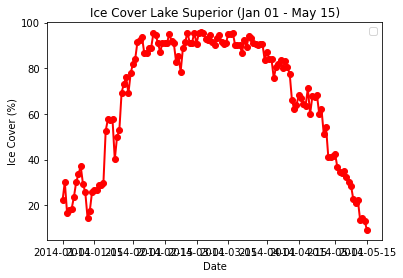

In [35]:
import calendar
import pandas as pd

ice_year = 2014
lake = 'Superior'
lake_var = 'sup'

figdir = './figs/'

path2data = "./noaa_glerl_ice/"

datafile = path2data+lake_var+"_ice_1973_2024.txt"
datafile

df = pd.read_csv(datafile, delim_whitespace=True)
df

yrs = df.columns.tolist()
df_yrs = pd.DataFrame()
for iyr in range(len(yrs)):
    # print(yrs[iyr])

    # Index year column
    df_yr = df[yrs[iyr]]
    # Check for leap year and remove feb-29
    if not calendar.isleap(int(yrs[iyr])):
        df_yr = df_yr.drop('Feb-29')
    # Add year to month-day row name, and convert to datetime
    df_yr = df_yr.reset_index()
    df_yr.iloc[:,0] = yrs[iyr]+'-'+df_yr.iloc[:,0]
    df_yr.iloc[:,0] = pd.to_datetime(df_yr.iloc[:,0])
    df_yr.columns = ['date', 'value']

    # Append to new dataframe
    df_yrs = pd.concat([df_yrs, df_yr], ignore_index=True)

df = df_yrs
# df.set_index(['date'], inplace=True)
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d %H:%M:%S')

# Filter between dates where there is appreciable ice cover
mask = (df['date'] >= str(ice_year)+'-1-1') & (df['date'] <= str(ice_year)+'-5-15')
# mask = (df['date'] >= str(ice_year)+'-2-15') & (df['date'] <= str(ice_year)+'-4-5')
df = df.loc[mask]
df = df.reset_index(drop=True)

# Plot ice averages

hh, ax = plt.subplots()

ax.plot(df["date"], df["value"], '-o',
              c='r', lw=2)

ax.set_xlabel('Date')
ax.set_ylabel('Ice Cover (%)')
startdate = df['date'].iloc[0].to_pydatetime().strftime('%b %d')
enddate = df['date'].iloc[-1].to_pydatetime().strftime('%b %d')
ax.set_title('Ice Cover Lake Superior ('+startdate+' - '+enddate+')')
ax.legend()




In [36]:
# # Grayling, MI
# US_GLMI = geoStation('US', 'GLMI', ['**'], ['BHZ'], label='Grayling, Michigan, USA')
# station_list = [US_GLMI]

# Ely, Minnesota, USA
US_EYMN = geoStation('US', 'EYMN', ['**'], ['BHZ'], label='Ely, Minnesota, USA')
station_list = [US_EYMN]

# # Erie, Pennsylvania, USA
# US_ERPA = geoStation('US', 'ERPA', ['**'], ['BHZ'], label='Erie, Pennsylvania, USA')
# station_list = [US_ERPA]

# # Sadowa, ON, CA
# CN_SADO = geoStation('CN', 'SADO', ['**'], ['BHZ'], label='Sadowa, ON, CA')
# station_list = [CN_SADO]

# tlist = [
#         #  ['2007-02-15', '2007-03-09'], 
#         #  ['2008-02-15', '2008-03-09'],
#          ['2009-02-15', '2009-03-09'],
#          ['2010-02-15', '2010-03-09'],
#          ['2011-02-15', '2011-03-09'],
#          ['2012-02-15', '2012-03-09'],
#          ['2013-02-15', '2013-03-09'],
#          ['2014-02-15', '2014-03-09'],
#          ['2015-02-15', '2015-03-09'],
#          ['2016-02-15', '2016-03-09'],
#          ['2017-02-15', '2017-03-09'],
#          ['2018-02-15', '2018-03-09'],
#          ['2019-02-15', '2019-03-09'],
#          ['2020-02-15', '2020-03-09'],
#          ['2021-02-15', '2021-03-09'],
#          ['2022-02-15', '2022-03-09'],
#          ['2023-02-15', '2023-03-09'],
#          ['2024-02-15', '2024-03-09'],
#          ]



In [ ]:
# Get seismic spectra

dof = 0
plotunit = 2

# Define fmin and fmax
fmin = 0.5 #1/3
fmax = 2 #1/0.65

# Get average noise properties
PSD_avg = 0
PSDs = []
df['PSD_band'] = np.nan
df['PSD_band_std'] = np.nan
df['PSD_band_stderr'] = np.nan
icnt = 0
pd.options.mode.chained_assignment = None  # default='warn' suppress annoying warning
for station in station_list:
    for iday in range(len(df)):
        tstart = df['date'][iday] - datetime.timedelta(1) # -24 hours
        tend = df['date'][iday] + datetime.timedelta(1) # +24 hours

        print('Working on '+tstart.strftime('%Y-%m-%d')+' to '+tend.strftime('%Y-%m-%d'))

        station.get_xml_histograms(tstart.strftime('%Y-%m-%d'), tend.strftime('%Y-%m-%d'))
        station.get_text_percentiles(tstart.strftime('%Y-%m-%d'), tend.strftime('%Y-%m-%d'))
        
        if len(station.text_percentiles[dof]) < 50:
            print('skipping '+tstart.strftime('%Y-%m-%d'))

            PSDs.append(np.nan*np.ones(freqs.shape))

            continue

        freqs = station.freqs[dof]
        
        PSD = 10*np.log10(station.text_percentiles[dof][50]/(2*np.pi*station.freqs[dof])**(2-plotunit))

        PSDs.append(PSD)

        df['PSD_band'][iday] = np.mean(PSD[(freqs>=fmin) & (freqs<=fmax)])

        df['PSD_band_std'][iday] = np.std(PSD[(freqs>=fmin) & (freqs<=fmax)])

        df['PSD_band_stderr'][iday] = np.std(PSD[(freqs>=fmin) & (freqs<=fmax)]) / np.sqrt(len(PSD[(freqs>=fmin) & (freqs<=fmax)]))
        
        PSD_avg = PSD_avg + PSD
        icnt+=1

PSD_avg = PSD_avg / icnt
PSDs = np.asarray(PSDs)


Working on 2013-12-31 to 2014-01-02
Working on 2014-01-01 to 2014-01-03
Working on 2014-01-02 to 2014-01-04
Working on 2014-01-03 to 2014-01-05
Working on 2014-01-04 to 2014-01-06
Working on 2014-01-05 to 2014-01-07
Working on 2014-01-06 to 2014-01-08
Working on 2014-01-07 to 2014-01-09
Working on 2014-01-08 to 2014-01-10
Working on 2014-01-09 to 2014-01-11
Working on 2014-01-10 to 2014-01-12
Working on 2014-01-11 to 2014-01-13
Working on 2014-01-12 to 2014-01-14
Working on 2014-01-13 to 2014-01-15
Working on 2014-01-14 to 2014-01-16
Working on 2014-01-15 to 2014-01-17
Working on 2014-01-16 to 2014-01-18
Working on 2014-01-17 to 2014-01-19
Working on 2014-01-18 to 2014-01-20
Working on 2014-01-19 to 2014-01-21
Working on 2014-01-20 to 2014-01-22
Working on 2014-01-21 to 2014-01-23
Working on 2014-01-22 to 2014-01-24
Working on 2014-01-23 to 2014-01-25
Working on 2014-01-24 to 2014-01-26
Working on 2014-01-25 to 2014-01-27
Working on 2014-01-26 to 2014-01-28
Working on 2014-01-27 to 201

Text(0.5, 1.0, 'Ice Cover Lake Superior (Feb 15 - March 8)')

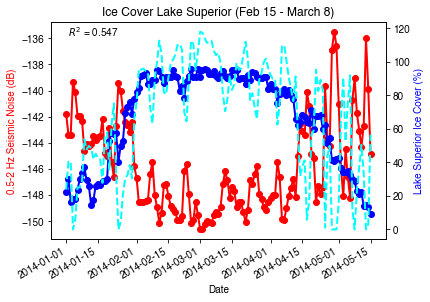

In [163]:
import scipy

# Calculate R^2 for seismic noise and ice cover
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(df["value"][~np.isnan(df["PSD_band"])], df["PSD_band"][~np.isnan(df["PSD_band"])])

# slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(df["PSD_band"][~np.isnan(df["PSD_band"])],df["value"][~np.isnan(df["PSD_band"])])

R2 = r_value**2

# # Slope and intercept from (Feb 15 - March 9 model)
# intercept = -139.958
# slope = -0.101

ice_pre = (df["PSD_band"]-intercept) / slope
# ice_pre = df["PSD_band"]*slope + intercept
ice_pre[ice_pre<0] = 0

# Plot seismic noise and ice averages

hh, ax = plt.subplots()

ax.plot(df["date"], df["PSD_band"], '-o',
              c='r', lw=2)
ax.set_ylabel(str(fmin)+'-'+str(fmax)+' Hz Seismic Noise (dB)', color='r')

ax2 = ax.twinx()
ax2.plot(df["date"], df["value"], '-o',
              c='b', lw=2)
ax2.plot(df["date"], ice_pre, '--',
              c='cyan', lw=2)
ax2.set_ylabel('Lake Superior Ice Cover (%)', color='b')

ax.annotate("$R^2$ = {:.3f}".format(R2), (0.05, 0.93), xycoords='axes fraction')

# ax.set_xticklabels(df['date'].dt.strftime('%Y-%m-%d'),rotation=45,ha='right')
# use formatters to specify major and minor ticks
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%Y-%m-%d"))
# Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax.get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')

ax.set_xlabel('Date')
ax.set_title('Ice Cover Lake Superior (Feb 15 - March 8)')
# ax.legend()

Text(0.5, 1.0, 'Seismic Noise Compared to Ice Cover (Feb 15 - March 8)')

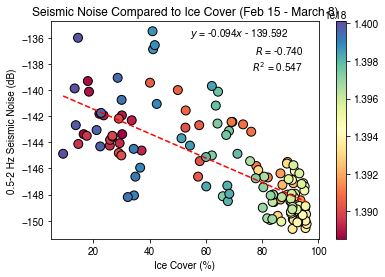

In [153]:
# Plot Average within band compared to ice cover

hh, ax = plt.subplots()

ice_nonan = df["value"][~np.isnan(df["PSD_band"])]
PSD_band_nonan = df["PSD_band"][~np.isnan(df["PSD_band"])]
date_nonan = df["date"][~np.isnan(df["PSD_band"])]

sc = ax.scatter(ice_nonan, PSD_band_nonan, marker='o', s=80,
              c=date_nonan, cmap='Spectral', edgecolor='black')
# ax.set_ylim([-190, -100])
cb = plt.colorbar(sc)

ax.plot([df["value"].min(),df["value"].max()], [df["value"].min()*slope+intercept,df["value"].max()*slope+intercept], '--',color='r')

ax.annotate("$y$ = {:.3f}$x$ - {:.3f}".format(slope,np.abs(intercept)), (0.52, 0.93), xycoords='axes fraction')
ax.annotate("$R$ = {:.3f}".format(r_value), (0.76, 0.85), xycoords='axes fraction')
ax.annotate("$R^2$ = {:.3f}".format(R2), (0.75, 0.77), xycoords='axes fraction')

ax.set_ylabel(str(fmin)+'-'+str(fmax)+' Hz Seismic Noise (dB)')

# ax.set_xlim([5e-3, 16])
ax.set_xlabel('Ice Cover (%)')
ax.set_title('Seismic Noise Compared to Ice Cover (Feb 15 - March 8)')
# ax.legend()

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


<Figure size 432x288 with 0 Axes>

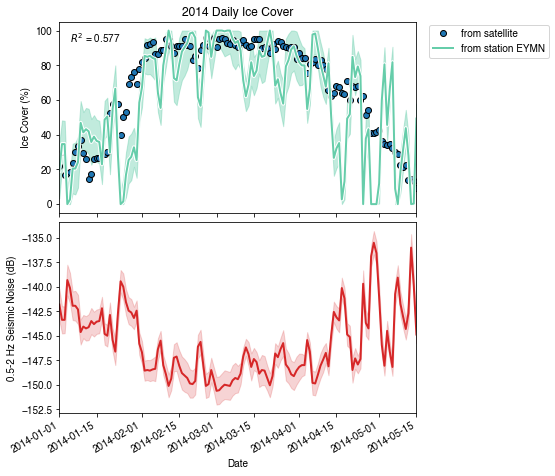

In [ ]:
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth

# Plot predictions for long-term tuned model

slope_longterm = -0.102
intercept_longterm = -139.847
ice_pre_longterm = (df["PSD_band"]-intercept_longterm) / slope_longterm
ice_pre_longterm[ice_pre_longterm<0]=0
ice_pre_longterm[ice_pre_longterm>100]=100

ice_pre_longterm_min = (df["PSD_band"]-df["PSD_band_stderr"]-intercept_longterm) / slope_longterm
ice_pre_longterm_min[ice_pre_longterm_min<0]=0
ice_pre_longterm_min[ice_pre_longterm_min>100]=100

ice_pre_longterm_max = (df["PSD_band"]+df["PSD_band_stderr"]-intercept_longterm) / slope_longterm
ice_pre_longterm_max[ice_pre_longterm_max<0]=0
ice_pre_longterm_max[ice_pre_longterm_max>100]=100

# Smoothed version
Nsm = 14
df["PSD_band_sm"] = smooth(df["PSD_band"],Nsm)
ice_pre_longterm_sm = (df["PSD_band_sm"]-intercept_longterm) / slope_longterm
ice_pre_longterm_sm[ice_pre_longterm_sm<0]=0
ice_pre_longterm_sm[ice_pre_longterm_sm>100]=100

# slope_longterm = -8.497257798287874
# intercept_longterm = -1183.4938618491747
# ice_pre_longterm = df["PSD_band"]*slope_longterm + intercept_longterm

r_longterm = np.corrcoef(ice_pre_longterm,df["value"])
R2_longterm = r_longterm[0,1]**2

# Plot seismic noise and ice averages
# fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

plt.tight_layout()
fig, ax = plt.subplots(2, 1, figsize=(6.4, 4.8*1.5), sharex=True)
# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.05) # Decrease hspace to reduce vertical spacing

# ax.plot(df["date"], df["PSD_band"], '-o',
#               c='tab:red', lw=2)
# ax.set_ylabel(str(fmin)+'-'+str(fmax)+' Hz Seismic Noise (dB)', color='tab:red')

# Upper subplot for Ice cover

# ax2 = ax.twinx()
ax[0].fill_between(df["date"],
                 ice_pre_longterm_min,
                 ice_pre_longterm_max, 
                 color='mediumaquamarine', alpha=0.4)
ax[0].plot(df["date"], df["value"], 'o',
              c='tab:blue', lw=1,markeredgecolor='k', label='from satellite')
ax[0].plot(df["date"], ice_pre_longterm, '-',
              c='w', lw=4)
ax[0].plot(df["date"], ice_pre_longterm, '-',
              c='mediumaquamarine', lw=2,label='from station '+station)
# ax[0].plot(df["date"], ice_pre_longterm_sm, ':',
#               c='w', lw=4)
# ax[0].plot(df["date"], ice_pre_longterm_sm, ':',
#               c='mediumaquamarine', lw=2,label='from station '+station)
ax[0].set_ylabel('Ice Cover (%)')

ax[0].annotate("$R^2$ = {:.3f}".format(R2_longterm), (0.03, 0.89), xycoords='axes fraction')

ax[0].set_title('2014 Daily Ice Cover')

ax[0].legend(bbox_to_anchor=(1.02, 1.01), loc='upper left')
ax[0].set_xlim([df["date"].min(), df["date"].max()])


# Lower subplot for seismic noise
ax[1].fill_between(df["date"],
                 df["PSD_band"]-df["PSD_band_stderr"],
                 df["PSD_band"]+df["PSD_band_stderr"], 
                 color='tab:red', alpha=0.2)
ax[1].plot(df["date"], df["PSD_band"], '-', c='tab:red', lw=2)
ax[1].set_ylabel(str(fmin) + '-' + str(fmax) + ' Hz Seismic Noise (dB)')
# ax[1].set_title('Seismic Noise and Ice Cover')


# ax.set_xticklabels(df['date'].dt.strftime('%Y-%m-%d'),rotation=45,ha='right')
# use formatters to specify major and minor ticks
ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax[1].xaxis.set_minor_formatter(mdates.DateFormatter("%Y-%m-%d"))
# Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax[1].get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')

ax[1].set_xlabel('Date')
# ax.set_title('Ice Cover Lake Superior (Feb 15 - March 8)')
# ax.legend()
ax[1].set_xlim([df["date"].min(), df["date"].max()])

try:
    plt.savefig(figdir+'a2a_daily_ice_estimate_'+station.station+'_'+str(ice_year)+'.pdf', bbox_inches='tight')
except:
    plt.savefig(figdir+'a2a_daily_ice_estimate_'+station+'_'+str(ice_year)+'.pdf', bbox_inches='tight')

In [ ]:
# r = np.corrcoef(ice_pre_longterm,df["value"])
# r[0,1]
r = np.corrcoef(df["PSD_band"],df["value"])
r


0.7593954562732208

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


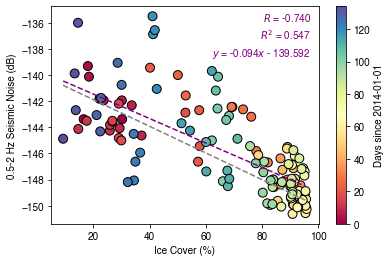

In [166]:
# Plot Average within band compared to ice cover

hh, ax = plt.subplots()

ice_nonan = df["value"][~np.isnan(df["PSD_band"])]
PSD_band_nonan = df["PSD_band"][~np.isnan(df["PSD_band"])]
date_nonan = df["date"][~np.isnan(df["PSD_band"])]

sc = ax.scatter(ice_nonan, PSD_band_nonan, marker='o', s=80,
              c=(date_nonan-date_nonan[0]).dt.days, cmap='Spectral', edgecolor='black')
# ax.set_ylim([-190, -100])
cb = plt.colorbar(sc)
cb.set_label(r'Days since '+date_nonan[0].to_pydatetime().strftime('%Y-%m-%d'))

ax.plot([df["value"].min(),df["value"].max()], [df["value"].min()*slope+intercept,df["value"].max()*slope+intercept], '--',color='purple')

ax.plot([df["value"].min(),df["value"].max()], [df["value"].min()*slope_longterm+intercept_longterm,df["value"].max()*slope_longterm+intercept_longterm], '--',color='gray')

ax.annotate("$y$ = {:.3f}$x$ - {:.3f}".format(slope,np.abs(intercept)), (0.60, 0.77), xycoords='axes fraction',color='purple')
ax.annotate("$R$ = {:.3f}".format(r_value), (0.79, 0.93), xycoords='axes fraction',color='purple')
ax.annotate("$R^2$ = {:.3f}".format(R2), (0.78, 0.85), xycoords='axes fraction',color='purple')

ax.set_ylabel(str(fmin)+'-'+str(fmax)+' Hz Seismic Noise (dB)')

# ax.set_xlim([5e-3, 16])
ax.set_xlabel('Ice Cover (%)')
# ax.set_title('Seismic Noise Compared to Ice Cover (Feb 15 - March 8)')
# ax.legend()

try:
    plt.savefig(figdir+'a2a_daily_ice_modelcompare_'+station.station+'_'+str(ice_year)+'.pdf', bbox_inches='tight')
except:
    plt.savefig(figdir+'a2a_daily_ice_modelcompare_'+station+'_'+str(ice_year)+'.pdf', bbox_inches='tight')

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


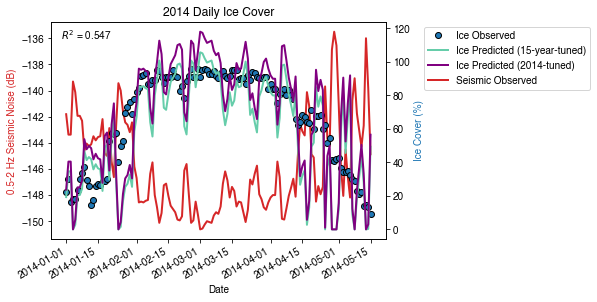

In [186]:
# Plot seismic noise and ice averages

hh, ax = plt.subplots()

ax.plot(df["date"], df["PSD_band"], '-',
              c='tab:red', lw=2)
ax.set_ylabel(str(fmin)+'-'+str(fmax)+' Hz Seismic Noise (dB)', color='tab:red')

ax2 = ax.twinx()
ax2.plot(df["date"], df["value"], 'o',
              c='tab:blue', lw=1,markeredgecolor='k', label='Ice Observed')
ax2.plot(df["date"], ice_pre_longterm, '-',
              c='mediumaquamarine', lw=2,label='Ice Predicted (15-year-tuned)')
ax2.plot(df["date"], ice_pre, '-',
              c='purple', lw=2,label='Ice Predicted (2014-tuned)')
ax2.plot(df["date"][0],ice_pre[0], '-',
              c='tab:red', lw=2,label='Seismic Observed')
ax2.set_ylabel('Ice Cover (%)', color='tab:blue')

ax2.legend(bbox_to_anchor=(1.1, 1.0), loc='upper left')


ax.set_title('2014 Daily Ice Cover')

ax.annotate("$R^2$ = {:.3f}".format(R2), (0.03, 0.92), xycoords='axes fraction')


# ax.set_xticklabels(df['date'].dt.strftime('%Y-%m-%d'),rotation=45,ha='right')
# use formatters to specify major and minor ticks
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%Y-%m-%d"))
# Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax.get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')

ax.set_xlabel('Date')
# ax.set_title('Ice Cover Lake Superior (Feb 15 - March 8)')
# ax.legend()

try:
    plt.savefig(figdir+'a2a_daily_ice_estimate_modelcompare_'+station.station+'_'+str(ice_year)+'.pdf', bbox_inches='tight')
except:
    plt.savefig(figdir+'a2a_daily_ice_estimate_modelcompare_'+station+'_'+str(ice_year)+'.pdf', bbox_inches='tight')

Text(0.5, 0, 'Date')

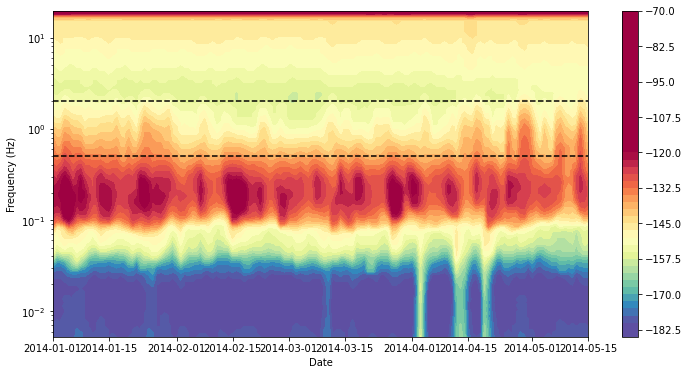

In [41]:
# Plot spectrogram of seismic noise

# Define fmin and fmax
fmin = 0.5 #1/3
fmax = 2 #1/0.65

fs,ts = np.meshgrid(freqs,df['date'])

fig = plt.figure(figsize=(12,6))
ax = plt.axes()
c = ax.contourf(ts,fs,PSDs,50, vmin=-180, vmax=-120, cmap='Spectral_r')
ax.plot([df['date'].min(), df['date'].max()],[fmin, fmin],'--',color='k')
ax.plot([df['date'].min(), df['date'].max()],[fmax, fmax],'--',color='k')
cb = plt.colorbar(c)
ax.set_yscale('log')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Date')

/tmp/ipykernel_8466/4060807354.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Spectral')


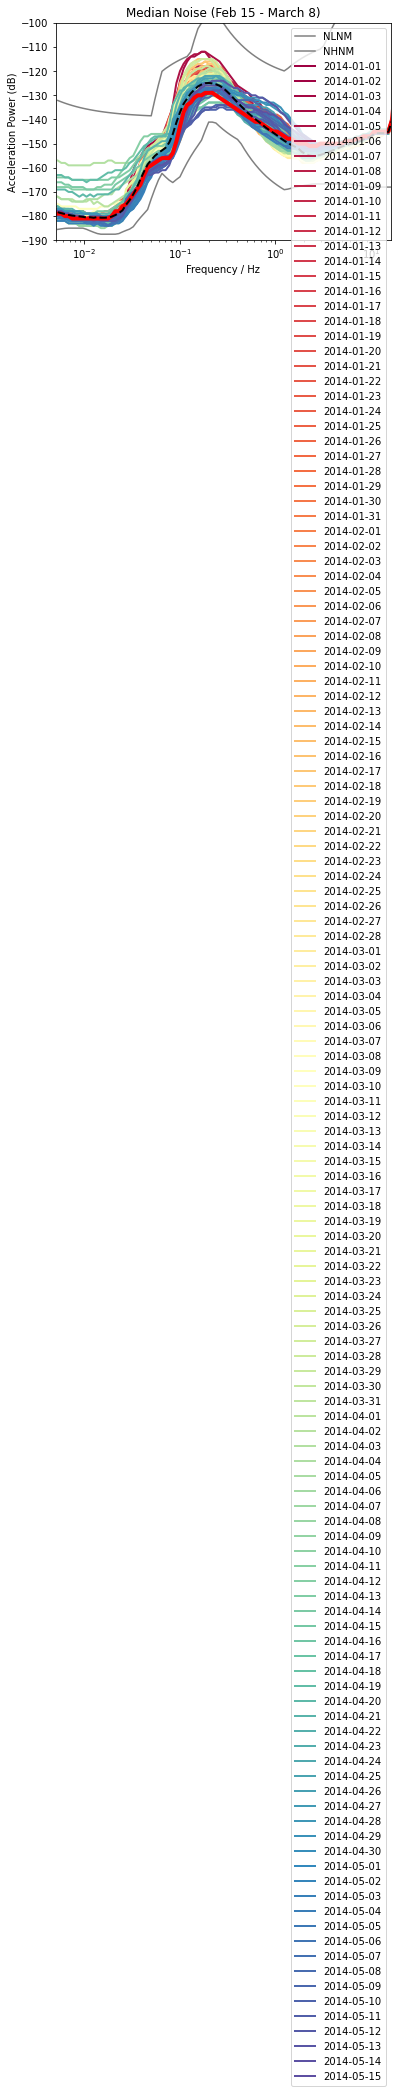

In [ ]:
import matplotlib.cm as cm

tlist = df['date']

cmap = cm.get_cmap('Spectral')
rgb = cmap(np.linspace(0,1,len(tlist)))

hh, ax = plt.subplots()

ax.plot(freqs, 10*np.log10(accNLNM(station.freqs[dof]) / (2*np.pi*station.freqs[dof])**(2-plotunit)),
              c='gray', label='NLNM')
ax.plot(freqs, 10*np.log10(accNHNM(station.freqs[dof]) / (2*np.pi*station.freqs[dof])**(2-plotunit)),
            c='gray', label='NHNM')

for sta in station_list:
    for iyr in range(len(tlist)):

        ax.plot(freqs, PSDs[iyr],
              c=rgb[iyr], lw=2, linestyle='-', label=tlist[iyr].strftime('%Y-%m-%d'))

ax.plot(freqs, PSDs[iyr],
              c='r', lw=4, linestyle='-')

ax.plot(freqs, PSD_avg,
              c='k', lw=2, linestyle='--')

ax.set_xscale('log')
ax.set_xlim([5e-3, 16])
ax.set_xlabel('Frequency / Hz')
ax.set_ylim([-190, -100])
ax.set_ylabel('Acceleration Power (dB)')
ax.set_title('Median Noise (Feb 15 - March 8)')
ax.legend()

/tmp/ipykernel_8466/3376571630.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Spectral')


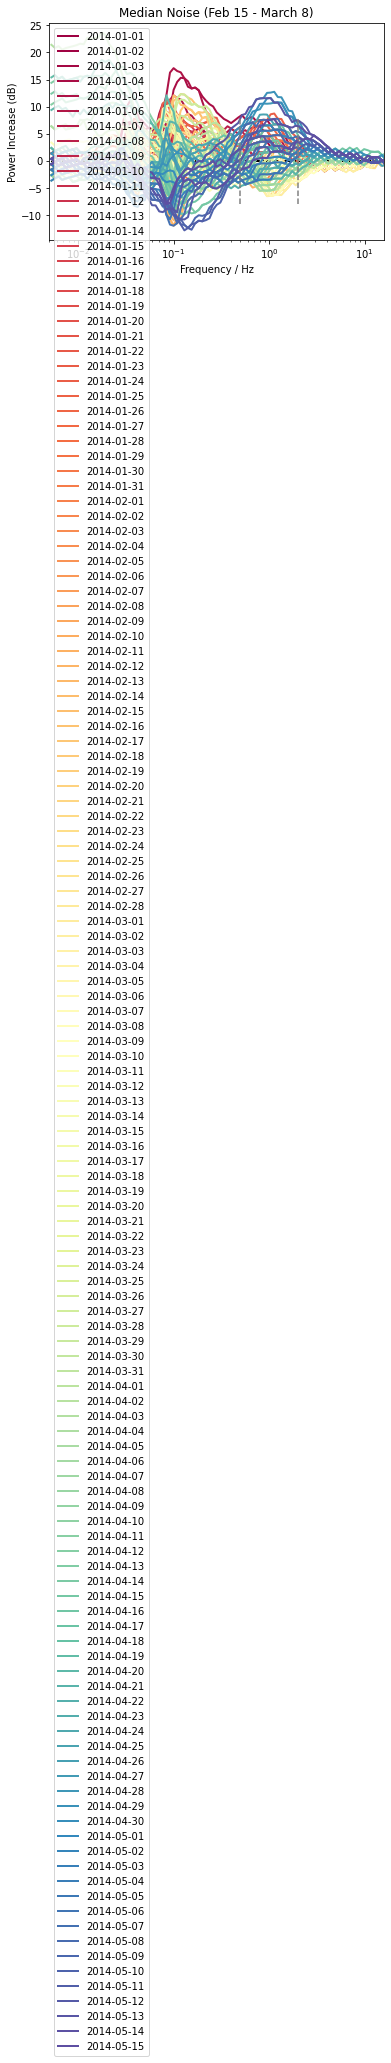

In [ ]:
import matplotlib.cm as cm

cmap = cm.get_cmap('Spectral')
rgb = cmap(np.linspace(0,1,len(tlist)))

hh, ax = plt.subplots()

ax.plot(freqs, PSD_avg*0,
              c='k', lw=2, linestyle='--')

dPSD_avg = []
for sta in station_list:
    for iyr in range(len(tlist)):

        dPSD = PSDs[iyr] - PSD_avg

        dPSD_avg.append(np.mean(dPSD[(freqs>=fmin) & (freqs<=fmax)]))

        ax.plot(freqs, dPSD,
              c=rgb[iyr], lw=2, linestyle='-', label=tlist[iyr].strftime('%Y-%m-%d'))

dPSD_avg = np.asarray(dPSD_avg)

# ax.plot(station.freqs[dof], 10*np.log10(station.text_percentiles[dof][50]/(2*np.pi*station.freqs[dof])**(2-plotunit)),
#               c='r', lw=4, linestyle='-')

ax.plot([fmin, fmin],[-8, 8],'--',color='gray')
ax.plot([fmax, fmax],[-8, 8],'--',color='gray')

ax.set_xscale('log')
ax.set_xlim([5e-3, 16])
ax.set_xlabel('Frequency / Hz')
# ax.set_ylim([-190, -100])
ax.set_ylabel('Power Increase (dB)')
ax.set_title('Median Noise (Feb 15 - March 8)')
ax.legend()

/Users/russell/anaconda3/envs/sitesearch/lib/python3.11/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/Users/russell/anaconda3/envs/sitesearch/lib/python3.11/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '


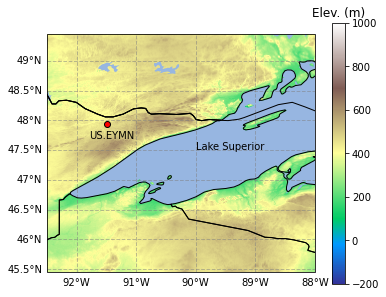

In [ ]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from netCDF4 import Dataset

network = 'US'
sta = 'EYMN'

client = Client("IRIS")
inventory = client.get_stations(network=network, station=sta)

stalat = inventory[0][0].latitude
stalon = inventory[0][0].longitude

# Load Topography dataset
path2grdfile = '/Users/russell/Lamont/GMT/grids/etopo1.grd'
etopodata = Dataset(path2grdfile)
lons_e = np.linspace(etopodata.variables['x_range'][0],
                    etopodata.variables['x_range'][1],
                    etopodata.variables['dimension'][0])
lats_e = np.linspace(etopodata.variables['y_range'][0],
                    etopodata.variables['y_range'][1],
                    etopodata.variables['dimension'][1])
etopo = etopodata.variables['z'][:]
etopo = np.reshape(etopo,etopodata.variables['dimension'][::-1])

# Generate the map
# Map projection
data_proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(6,6))
ax = plt.axes(projection=data_proj)
ax.set_extent([stalon-1, stalon+3.5, stalat-2.5, stalat+1.5], crs=data_proj)
img_extent = (-180, 180, -90, 90)
pos = ax.imshow(etopo, origin='upper', extent=img_extent, transform=data_proj,
            cmap='terrain', alpha=1, zorder=-1)
cb = plt.colorbar(pos, ax=ax, shrink=0.8)
cb.ax.set_title('Elev. (m)')
cmax = etopo.max()
cmin = etopo.min()
pos.set_clim(-200,1000)
ax.add_feature(cfeature.OCEAN,facecolor=cfeature.COLORS['water'])
ax.add_feature(cfeature.LAKES.with_scale('10m'), facecolor=cfeature.COLORS['water'], zorder=0)
# ax.add_feature(cfeature.RIVERS)
ax.coastlines(zorder=0)
ax.add_feature(cfeature.BORDERS.with_scale('50m'))
ax.add_feature(cfeature.STATES.with_scale('50m'))
ax.annotate('Lake Superior', (-90,47.5), xycoords='data', transform=data_proj, color='k')

# Plot station
ax.plot(
    stalon,stalat, marker='o',
    c='r',
    markeredgecolor='black', transform=data_proj)
# ax.set_xlim(minlongitude,maxlongitude)
# ax.set_ylim(minlatitude,maxlatitude)
ax.annotate(network+'.'+sta, (stalon-0.3,stalat-0.25), xycoords='data', transform=data_proj, color='k')

gl = ax.gridlines(crs=data_proj, draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--', zorder=0)
gl.xlabels_top = False
gl.ylabels_right = False

plt.savefig('station_map.pdf')

